In [35]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [39]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# https://research.unsw.edu.au/projects/unsw-nb15-dataset
"""
    download dataset in above link
"""

In [67]:
dataPath = "dataset/UNSW_NB15_training-set.csv" 
test_path = "dataset/UNSW_NB15_testing-set.csv" 
df = pd.read_csv(dataPath)
test_df = pd.read_csv(test_path)
df.head(3)

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0


In [75]:
df = df.drop(columns=['id','attack_cat'])
label = df["label"]
df = df.drop("label",axis = 1)

test_df = test_df.drop(columns=['id','attack_cat'])
test_label = test_df["label"]
test_df = test_df.drop("label",axis=1)

KeyError: "['id', 'attack_cat'] not found in axis"

In [76]:
print(label.value_counts())
print(test_label.value_counts())

label
1    119341
0     56000
Name: count, dtype: int64
label
1    45332
0    37000
Name: count, dtype: int64


In [77]:
df = pd.get_dummies(df)
test_df = pd.get_dummies(test_df)

In [79]:
test_df = test_df.reindex(columns=df.columns, fill_value=0)

In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_train = X_scaled[label == 0]

X_test_scaled = scaler.transform(test_df)

In [81]:
class CustomDataset(Dataset):
    def __init__(self,data):
        self.data = torch.tensor(data,dtype=torch.float32)
    
    def __len__(self):
        return self.data.shape[0]
    
    def __getitem__(self, index):
        return self.data[index]

In [82]:
class AutoEncoder(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(32,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,input_dim)
        )
    def forward(self,x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [83]:
train_dataset = CustomDataset(X_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [84]:
feature_dim = X_train.shape[1]
model = AutoEncoder(input_dim=feature_dim).to(device)
criteriaon = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 1e-3)

In [90]:
epochs = 5
losses = []
for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        x = batch.to(device)
        output = model(x)
        loss = criteriaon(output,x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print(f"Epoch {epoch} : Loss = {loss.item():.3f}")

Epoch 0 : Loss = 0.004
Epoch 1 : Loss = 0.014
Epoch 2 : Loss = 0.003
Epoch 3 : Loss = 0.004
Epoch 4 : Loss = 0.003


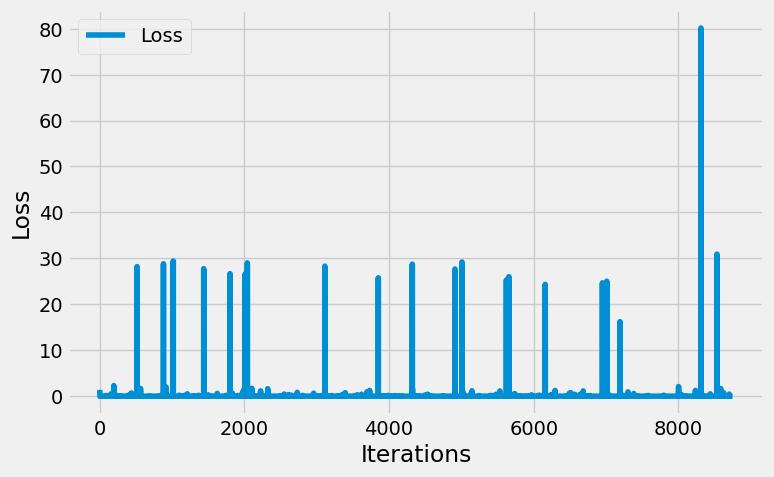

In [94]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [95]:
model.eval()
threshold = 0.01  # Set based on benign validation data
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    output = model (X_test_tensor)
    loss = torch.mean((X_test_tensor-output)**2,dim = 1)

y_pred = (loss>threshold).cpu().numpy()

y_true = test_label.values

In [96]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malicious"]))



Confusion Matrix:
[[33080  3920]
 [ 9220 36112]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.78      0.89      0.83     37000
   Malicious       0.90      0.80      0.85     45332

    accuracy                           0.84     82332
   macro avg       0.84      0.85      0.84     82332
weighted avg       0.85      0.84      0.84     82332



In [97]:
# Save only the model's state dictionary (recommended)
torch.save(model.state_dict(), "autoencoder_model.pth")

In [ ]:
import numpy as np
import torch

def extract_features_from_url(url, feature_columns, scaler):
    """
    Stub function that takes a URL string and returns a numeric feature vector
    matching your model's expected input.
    
    For now, it returns dummy zero features with some example fixed values.
    
    Parameters:
    - url: str, the URL to analyze
    - feature_columns: list of str, names of features expected by the model
    - scaler: fitted sklearn scaler to scale the features
    
    Returns:
    - scaled_features: numpy array of shape (1, num_features)
    """
    num_features = len(feature_columns)
    
    # Create dummy features (replace with real extraction logic)
    features = np.zeros(num_features)
    
    # Example: let's say you want to encode "protocol_tcp" = 1 if URL uses http/https
    if url.startswith("http"):
        if "protocol_tcp" in feature_columns:
            idx = feature_columns.index("protocol_tcp")
            features[idx] = 1
    
    # Example: encode service_http = 1 if URL uses HTTP
    if url.startswith("http://") and "service_http" in feature_columns:
        idx = feature_columns.index("service_http")
        features[idx] = 1
    elif url.startswith("https://") and "service_https" in feature_columns:
        idx = feature_columns.index("service_https")
        features[idx] = 1
    
    # Add any other heuristic you want here...
    
    # Scale features
    scaled_features = scaler.transform(features.reshape(1, -1))
    
    return scaled_features
